# Phase 3 : Modélisation et Validation avec XGBoost

Ce notebook prend en charge les datasets finaux issus de la phase d'ingénierie des caractéristiques.

## Objectifs de cette phase
- Construire un **Pipeline de prétraitement** robuste pour gérer les variables catégorielles (imputation et encodage) et les valeurs manquantes.
- Définir une **métrique de Coût Métier** sur-mesure (pénalisant lourdement les Faux Négatifs).
- Entraîner un modèle **XGBoost** de référence (Baseline) optimisé pour le déséquilibre des classes (`scale_pos_weight`).
- Évaluer la robustesse via une **Validation Croisée Stratifiée**.
- Visualiser les résultats financiers sur le jeu de test.

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn & XGBoost
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import make_scorer, confusion_matrix, classification_report
from xgboost import XGBClassifier

## 2. Chargement des données finales

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Chargement des datasets finaux...")
train_final = pd.read_csv(DATA_PROCESSED / "train_final.csv")

print(f"Dimensions du jeu d'entraînement : {train_final.shape}")

Chargement des datasets finaux...
Dimensions du jeu d'entraînement : (307511, 178)


## 3. Préparation du Pipeline Scikit-Learn

Les algorithmes arborescents comme XGBoost gèrent nativement les variables numériques non mises à l'échelle. En revanche, ils nécessitent un traitement strict des variables textuelles (catégorielles).

In [3]:
# Séparation de la cible (y) et des variables (X)
X = train_final.drop(columns=['TARGET', 'SK_ID_CURR'])
y = train_final['TARGET']

# Identification automatique des types de colonnes
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f"Nombre de variables numériques : {len(numeric_cols)}")
print(f"Nombre de variables catégorielles : {len(categorical_cols)}")

# Création des transformateurs
# 1. Pour les catégories : on remplit les NaN par 'missing' puis on encode en binaire (One-Hot)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2. Pour les numériques : XGBoost gère les NaN, mais on s'assure qu'il n'y a pas de problème de format
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Optionnel pour XGBoost, mais bonne pratique globale
])

# Assemblage du préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Création du jeu d'évaluation local (Hold-out test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Nombre de variables numériques : 160
Nombre de variables catégorielles : 16


## 4. Définition de la métrique métier (Business Cost)

L'Accuracy est trompeuse avec 92% de clients solvables. L'objectif de la banque est de minimiser ses pertes.

- **Faux Négatif (FN)** : On prête à un profil à risque. Coût = 10 (Perte du capital).
- **Faux Positif (FP)** : On refuse un bon client. Coût = 1 (Perte d'opportunité).

In [4]:
def custom_business_cost(y_true, y_pred):
    """Calcule le coût financier moyen par prédiction."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    cost_fn = 10  
    cost_fp = 1   
    
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    return total_cost / len(y_true)

# greater_is_better=False indique à Scikit-Learn qu'il faut minimiser ce score
business_scorer = make_scorer(custom_business_cost, greater_is_better=False)

## 5. Construction et Évaluation du Pipeline XGBoost

In [6]:
# Calcul du ratio de déséquilibre pour XGBoost
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Ratio de déséquilibre des classes calculé : {ratio:.2f}")

# Création du pipeline complet
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=ratio, 
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1 # On laisse XGBoost utiliser le processeur à 100% pour construire ses arbres
    ))
])

# Validation croisée stratifiée
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nLancement de la validation croisée séquentielle (Veuillez patienter ~5 à 10 min)...\n")

# LA CORRECTION EST ICI : n_jobs=1 force l'exécution d'un fold à la fois pour sauver la RAM
cv_results = cross_validate(
    xgb_pipeline, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    scoring={'business_cost': business_scorer, 'f1': 'f1', 'recall': 'recall', 'roc_auc': 'roc_auc'},
    n_jobs=1 
)

print("--- Performances Moyennes (Cross-Validation 5 Folds) ---")
print(f"ROC-AUC Score : {np.mean(cv_results['test_roc_auc']):.4f}")
print(f"Rappel (Détection des défauts) : {np.mean(cv_results['test_recall']):.4f}")
print(f"F1-Score : {np.mean(cv_results['test_f1']):.4f}")
print(f"Coût Métier Moyen (Pénalité par dossier) : {np.abs(np.mean(cv_results['test_business_cost'])):.4f}")

Ratio de déséquilibre des classes calculé : 11.39

Lancement de la validation croisée séquentielle (Veuillez patienter ~5 à 10 min)...

--- Performances Moyennes (Cross-Validation 5 Folds) ---
ROC-AUC Score : 0.7601
Rappel (Détection des défauts) : 0.6002
F1-Score : 0.2903
Coût Métier Moyen (Pénalité par dossier) : 0.5274


## 6. Analyse visuelle et financière sur le jeu de test


--- Rapport de Classification (Jeu de Test) ---
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     56538
           1       0.19      0.63      0.29      4965

    accuracy                           0.76     61503
   macro avg       0.58      0.70      0.57     61503
weighted avg       0.90      0.76      0.81     61503


🏦 Simulation financière : Pénalité totale sur ce portefeuille de test = 31,613 points.


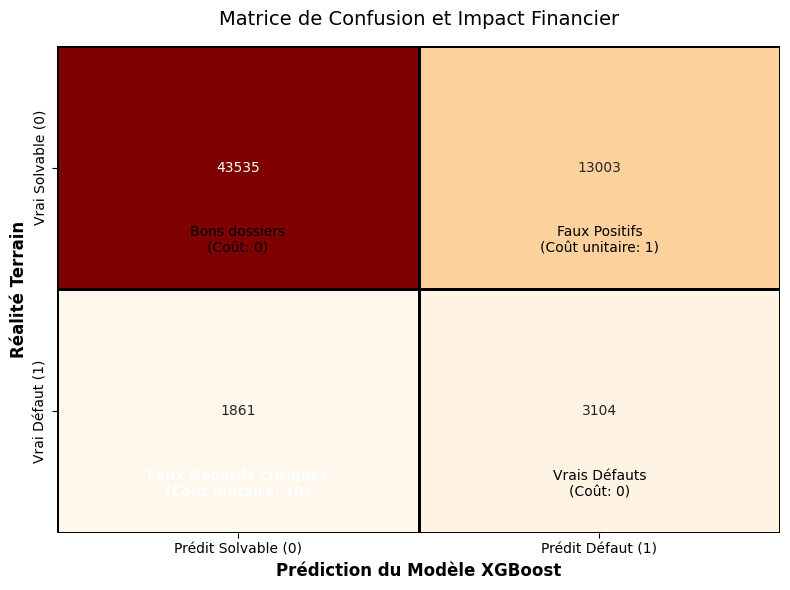

In [7]:
# Entraînement final sur tout le jeu d'entraînement
xgb_pipeline.fit(X_train, y_train)

# Prédictions sur le jeu de test (X_test)
y_pred = xgb_pipeline.predict(X_test)

print("\n--- Rapport de Classification (Jeu de Test) ---")
print(classification_report(y_test, y_pred))

# Création de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
cost_test = custom_business_cost(y_test, y_pred) * len(y_test)

print(f"\n🏦 Simulation financière : Pénalité totale sur ce portefeuille de test = {cost_test:,.0f} points.")

# Visualisation optimisée (Principes de Gestalt : Contraste sur les zones critiques)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', cbar=False,
            xticklabels=['Prédit Solvable (0)', 'Prédit Défaut (1)'], 
            yticklabels=['Vrai Solvable (0)', 'Vrai Défaut (1)'],
            linewidths=1, linecolor='black')

# Ajout d'annotations pour expliciter le coût métier
plt.text(0.5, 0.8, f"Bons dossiers\n(Coût: 0)", ha='center', va='center', color='black', fontsize=10)
plt.text(1.5, 0.8, f"Faux Positifs\n(Coût unitaire: 1)", ha='center', va='center', color='black', fontsize=10)
plt.text(0.5, 1.8, f"Faux Négatifs critiques\n(Coût unitaire: 10)", ha='center', va='center', color='white', fontsize=10, fontweight='bold')
plt.text(1.5, 1.8, f"Vrais Défauts\n(Coût: 0)", ha='center', va='center', color='black', fontsize=10)

plt.title('Matrice de Confusion et Impact Financier', fontsize=14, pad=15)
plt.ylabel('Réalité Terrain', fontsize=12, fontweight='bold')
plt.xlabel('Prédiction du Modèle XGBoost', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
import joblib
import os

print("Sauvegarde du modèle et des données pour le Dashboard...")

# 1. Créer le dossier 'models' à la racine s'il n'existe pas
os.makedirs(PROJECT_ROOT / "models", exist_ok=True)

# 2. Sauvegarder le pipeline complet (Préprocesseur + XGBoost)
joblib.dump(xgb_pipeline, PROJECT_ROOT / "models" / "xgboost_baseline.pkl")

# 3. Sauvegarder le jeu de test pour que Streamlit puisse l'utiliser
# On recolle y_test à X_test juste pour le fichier
test_sample = X_test.copy()
test_sample['TARGET'] = y_test
test_sample.to_csv(DATA_PROCESSED / "test_sample_dashboard.csv", index=False)

print("✅ Modèle sauvegardé dans 'models/xgboost_baseline.pkl'")
print("✅ Données de test sauvegardées dans 'data/processed/test_sample_dashboard.csv'")

Sauvegarde du modèle et des données pour le Dashboard...
✅ Modèle sauvegardé dans 'models/xgboost_baseline.pkl'
✅ Données de test sauvegardées dans 'data/processed/test_sample_dashboard.csv'
